# Лабораторная работа: Ансамбли моделей машинного обучения (Часть 1)

**Цель:** Изучение ансамблевых методов машинного обучения: бэггинг, случайный лес, AdaBoost и градиентный бустинг.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier

sns.set(style="whitegrid")


In [2]:
# Используем снова Titanic для классификации
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Первые строки
print("Первые 5 строк датасета:")
display(df.head())

# Информация
print("\nИнформация о датасете:")
df.info()

# Статистика
print("\nСтатистика по числовым признакам:")
display(df.describe(include='all'))


Первые 5 строк датасета:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Статистика по числовым признакам:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [3]:
# Предобработка
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
df.dropna(inplace=True)

# Кодирование пола
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

# Разделение признаков и целевой переменной
X = df.drop('Survived', axis=1)
y = df['Survived']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (571, 6)
Размер тестовой выборки: (143, 6)


In [4]:
# Бэггинг с базовым классификатором (дерево решений)
bagging_model = BaggingClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)

# Случайный лес
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Сверхслучайные деревья (Extra Trees)
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
et_model.fit(X_train, y_train)

# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

# Градиентный бустинг
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [5]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n📊 {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

evaluate_model("Бэггинг (BaggingClassifier)", bagging_model, X_test, y_test)
evaluate_model("Случайный лес (RandomForest)", rf_model, X_test, y_test)
evaluate_model("Сверхслучайные деревья (ExtraTrees)", et_model, X_test, y_test)
evaluate_model("AdaBoost", ada_model, X_test, y_test)
evaluate_model("Градиентный бустинг", gb_model, X_test, y_test)



📊 Бэггинг (BaggingClassifier)
Accuracy: 0.75
Confusion Matrix:
[[68 19]
 [17 39]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        87
           1       0.67      0.70      0.68        56

    accuracy                           0.75       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143


📊 Случайный лес (RandomForest)
Accuracy: 0.80
Confusion Matrix:
[[73 14]
 [15 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83        87
           1       0.75      0.73      0.74        56

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143


📊 Сверхслучайные деревья (ExtraTrees)
Accuracy: 0.78
Confusion Matrix:
[[71 16]
 [15 41]]
Classification Report:
              preci

C:\Users\tdash\AppData\Local\Temp\ipykernel_17464\2275057930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


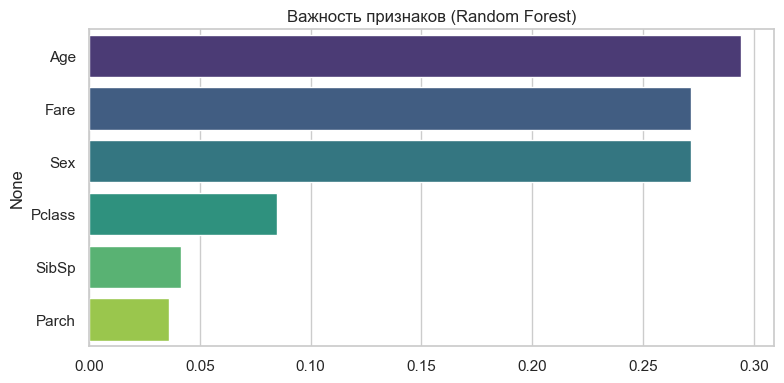

C:\Users\tdash\AppData\Local\Temp\ipykernel_17464\2275057930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


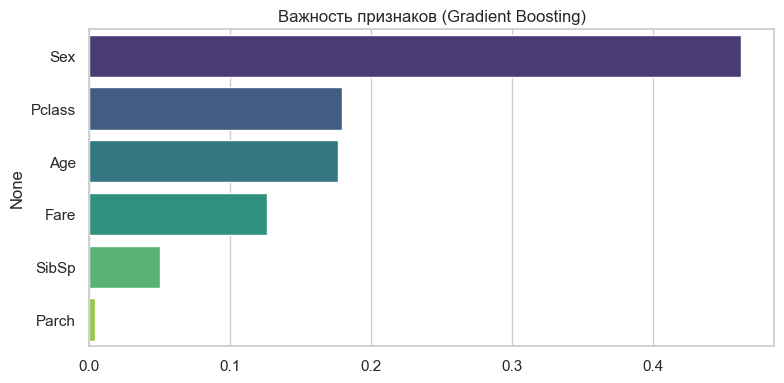

In [6]:
# Важность признаков: Случайный лес и Градиентный бустинг
def plot_feature_importance(model, model_name):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 4))
    plt.title(f"Важность признаков ({model_name})")
    sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf_model, "Random Forest")
plot_feature_importance(gb_model, "Gradient Boosting")


C:\Users\tdash\AppData\Local\Temp\ipykernel_17464\684681739.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies, y=model_names, palette="Set2")


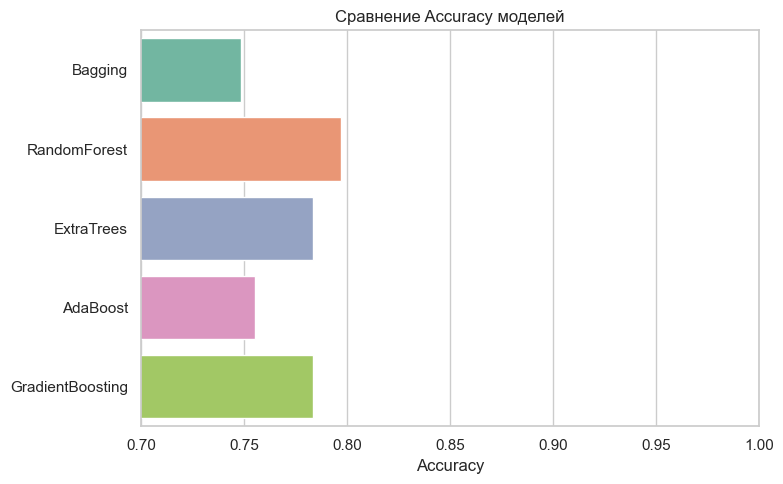

In [7]:
# Сравнение accuracy моделей
model_names = ["Bagging", "RandomForest", "ExtraTrees", "AdaBoost", "GradientBoosting"]
models = [bagging_model, rf_model, et_model, ada_model, gb_model]
accuracies = [accuracy_score(y_test, m.predict(X_test)) for m in models]

plt.figure(figsize=(8, 5))
sns.barplot(x=accuracies, y=model_names, palette="Set2")
plt.title("Сравнение Accuracy моделей")
plt.xlabel("Accuracy")
plt.xlim(0.7, 1.0)
plt.tight_layout()
plt.show()
